In [37]:
import pandas as pd
import numpy as np

In [38]:
url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'
df = pd.read_csv(url)
df.head(2)

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1


In [39]:
df.isnull().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [40]:
num_cats = list(df.select_dtypes('number'))
for c in num_cats:
    df[c] = df[c].fillna(0.0)
df = df.fillna('NA')

In [41]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

In [42]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values


df_train = df_train.drop(columns=['converted'])
df_val = df_val.drop(columns=['converted'])
df_test = df_test.drop(columns=['converted'])

In [43]:
from sklearn.metrics import roc_auc_score
numerical = list(df_train.select_dtypes('number'))
for c in numerical:
    feature = df_train[c]
    score = roc_auc_score(y_train, feature)
    if (score<0.5):
        feature = -feature
        score = roc_auc_score(y_train, feature)
    print(f'{c}: {score}')

annual_income: 0.6081977776250831
number_of_courses_viewed: 0.7229894623989618
interaction_count: 0.7649203047563227
lead_score: 0.7882254810906102


In [44]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

def train(df_train, y_train, C=1):
    dv = DictVectorizer(sparse=False)
    dicts_train = df_train.to_dict(orient='records')
    X_train = dv.fit_transform(dicts_train)
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    return dv, model

def predict(df_val, dv, model):
    dicts_val = df_val.to_dict(orient='records')
    X_val = dv.transform(dicts_val)
    y_pred = model.predict_proba(X_val)[:,1]
    return y_pred

In [45]:
dv, model = train(df_train, y_train)
y_pred = predict(df_val, dv, model)
score = roc_auc_score(y_val, y_pred)
round(score,3)

0.732

In [46]:
thresholds = np.linspace(0,1,101)
scores = []
for t in thresholds:
    actual_positive = (y_val==1)
    actual_negative = (y_val==0)
    
    predicted_positive = (y_pred>=t)
    predicted_negative = (y_pred<t)
    
    tn = (actual_negative & predicted_negative).sum()
    tp = (actual_positive & predicted_positive).sum()
    
    fp = (actual_negative & predicted_positive).sum()
    fn = (actual_positive & predicted_negative).sum()
    
    scores.append((t, tp, fp, tn, fn,))
columns = ['threshold', 'tp', 'fp', 'tn', 'fn',]
df_scores = pd.DataFrame(scores, columns=columns)

In [47]:
df_scores['p'] = (df_scores.tp / (df_scores.tp + df_scores.fp).replace(0, np.nan)).fillna(0)
df_scores['r'] = (df_scores.tp / (df_scores.tp + df_scores.fn).replace(0, np.nan)).fillna(0)
df_scores = df_scores[(df_scores.p != 0) | (df_scores.r != 0)]

In [48]:
import matplotlib.pyplot as plt

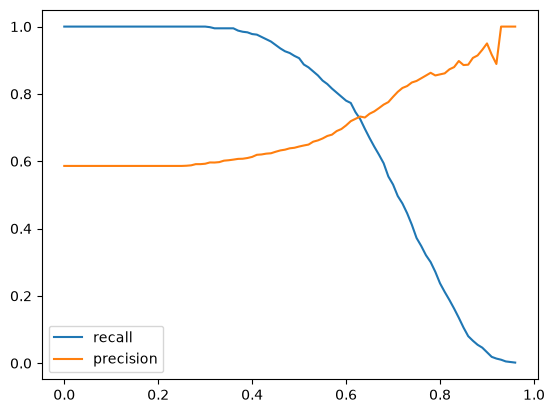

In [49]:
plt.plot(df_scores.threshold, df_scores['r'], label='recall')
plt.plot(df_scores.threshold, df_scores['p'], label='precision')
plt.legend()

In [50]:
df_scores['diff'] = np.abs(df_scores.p - df_scores.r)

In [51]:
df_scores[df_scores['diff']==df_scores['diff'].min()]

,threshold,tp,fp,tn,fn,p,r,diff
63,0.63,425,155,259,161,0.732759,0.725256,0.007503


In [52]:
df_scores['f1'] = 2* (df_scores.p*df_scores.r) / (df_scores.p+df_scores.r)
df_scores[df_scores['f1']==df_scores['f1'].max()]

,threshold,tp,fp,tn,fn,p,r,diff,f1
41,0.41,572,352,62,14,0.619048,0.976109,0.357062,0.757616


In [53]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=1)
df_full_train = df_full_train.reset_index(drop=True)
scores = []
for train_idx, val_idx in kfold.split(df_full_train):
    df_train_fold = df_full_train.iloc[train_idx]
    df_val_fold = df_full_train.iloc[val_idx]
    
    y_train_fold = df_train_fold.converted.values
    y_val_fold = df_val_fold.converted.values
    
    df_train_fold = df_train_fold.drop(columns=['converted'])
    df_val_fold = df_val_fold.drop(columns=['converted'])
    
    dv, model = train(df_train_fold, y_train_fold)
    y_pred_fold = predict(df_val_fold, dv, model)
    score = roc_auc_score(y_val_fold, y_pred_fold)
    scores.append(score)
std = round(np.std(scores),3)
std

np.float64(0.007)

In [54]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)
df_full_train = df_full_train.reset_index(drop=True)
c_values = [0.000001, 0.001, 1]
for c in c_values:
    scores = []
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train_fold = df_full_train.iloc[train_idx]
        df_val_fold = df_full_train.iloc[val_idx]
        
        y_train_fold = df_train_fold.converted.values
        y_val_fold = df_val_fold.converted.values
        
        df_train_fold = df_train_fold.drop(columns=['converted'])
        df_val_fold = df_val_fold.drop(columns=['converted'])
        
        dv,model = train(df_train_fold, y_train_fold, c)
        
        y_pred_fold = predict(df_val_fold, dv, model)
        score = roc_auc_score(y_val_fold, y_pred_fold)
        scores.append(score)
    print(f"{c}: {round(np.mean(scores),3)} {round(np.std(scores),3)}")

1e-06: 0.617 0.019
0.001: 0.749 0.01
1: 0.732 0.007
